In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

Saving cats_and_dogs.zip to cats_and_dogs.zip


In [4]:
import zipfile

zip_path = "cats_and_dogs.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("cats_and_dogs")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files in os.walk("cats_and_dogs"):
    print(root, "->", dirs, "| Images:", len(files))

cats_and_dogs -> ['cats_set', 'dogs_set'] | Images: 0
cats_and_dogs/cats_set -> [] | Images: 500
cats_and_dogs/dogs_set -> [] | Images: 500


In [6]:
image_size = (64, 64)

X = []
y = []

folders = {
    "cats_and_dogs/cats_set": 0,
    "cats_and_dogs/dogs_set": 1
}

for folder, label in folders.items():
    for filename in os.listdir(folder):
        image_path = os.path.join(folder, filename)

        try:
            image = Image.open(image_path).convert("RGB")
            image = image.resize(image_size)

            image_array = np.array(image)
            image_array = image_array.flatten()

            X.append(image_array)
            y.append(label)

        except:
            pass

X = np.array(X)
y = np.array(y)

print("Total Images:", len(X))
print("Image Data Shape:", X.shape)
print("Labels Shape:", y.shape)

Total Images: 1000
Image Data Shape: (1000, 12288)
Labels Shape: (1000,)


In [7]:
X = X / 255.0

print("Image data normalized successfully!")
print("Minimum value:", X.min())
print("Maximum value:", X.max())

Image data normalized successfully!
Minimum value: 0.0
Maximum value: 1.0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (800, 12288)
Testing Images: (200, 12288)


In [9]:
svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [10]:
y_pred = svm_model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 Predictions:", y_pred[:10])

Predictions completed successfully!
First 10 Predictions: [1 0 1 0 0 1 0 0 0 0]


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

Model Accuracy: 0.5
Model Accuracy Percentage: 50.0 %

Classification Report:
              precision    recall  f1-score   support

         Cat       0.50      0.53      0.51       100
         Dog       0.50      0.47      0.48       100

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200



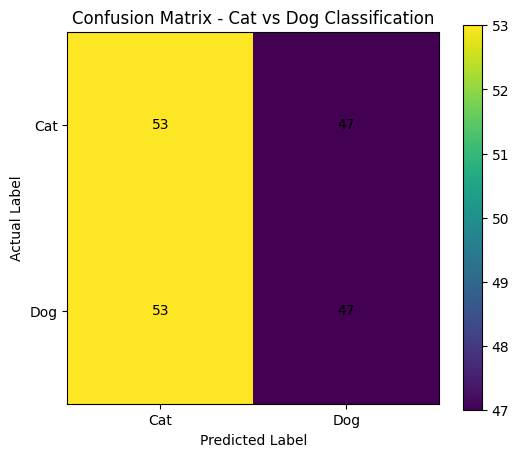

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Cat vs Dog Classification")
plt.colorbar()

plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

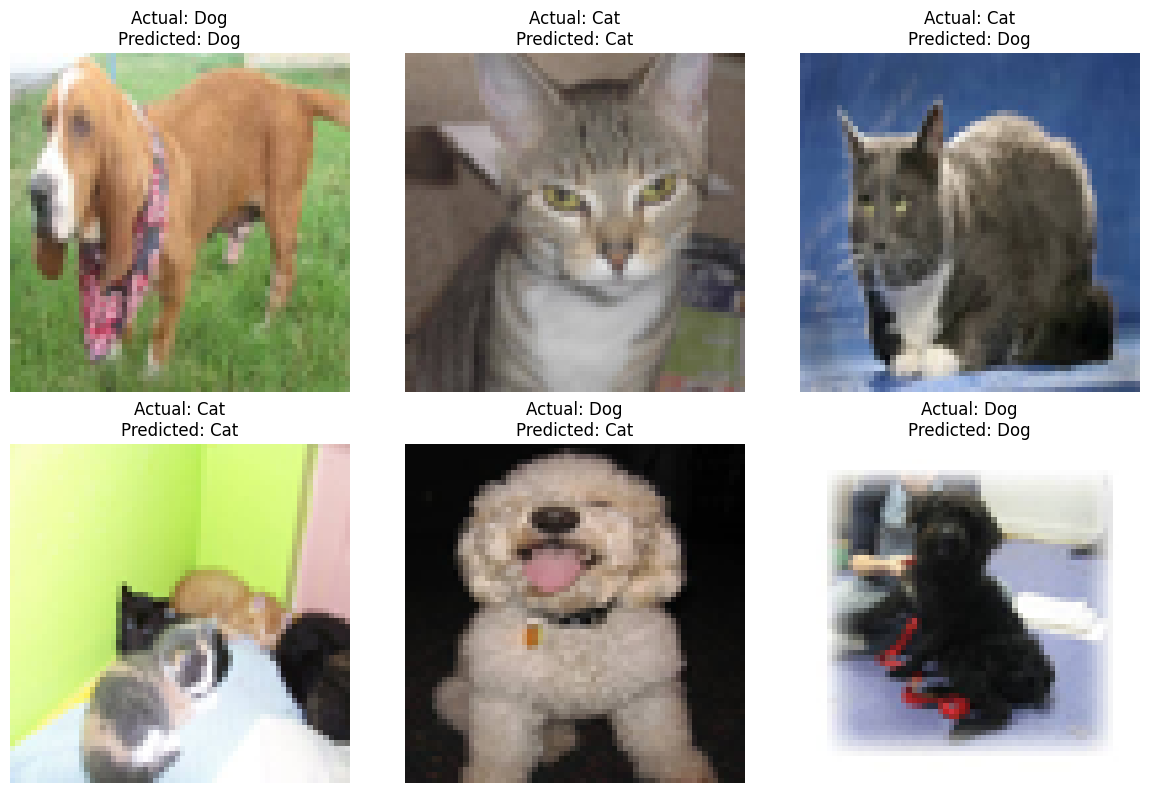

In [13]:
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    image = X_test[i].reshape(64, 64, 3)

    plt.imshow(image)

    actual = "Cat" if y_test[i] == 0 else "Dog"
    predicted = "Cat" if y_pred[i] == 0 else "Dog"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import joblib

joblib.dump(svm_model, "cat_dog_svm_model.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!


In [15]:
from google.colab import files

files.download("cat_dog_svm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>